# Mission Eagle-1 — Pilote automatique d'atterrissage lunaire

**Entreprise** : AstroDynamics  
**Rôle** : Ingénieur Machine Learning Junior (équipe R&D)  
**Mission** : Concevoir un agent d'apprentissage par renforcement (RL) capable de piloter le module Eagle-1 pour un atterrissage lunaire précis et économe en carburant.  
**Critère de succès** : récompense moyenne ≥ 200 sur 100 épisodes consécutifs.

---

## Démarche

1. [Exploration de l'environnement LunarLander-v3](#1-exploration)
2. [Choix de l'algorithme](#2-algo)
3. [Baseline : DQN avec hyperparamètres par défaut](#3-baseline)
4. [Optimisation des hyperparamètres](#4-tuning)
5. [Évaluation finale du meilleur modèle](#5-eval)
6. [Formatage des données pour l'API](#6-format)
7. [Livrables annexes : API, GUI, Dashboard, Vidéo](#7-livrables)
8. [Conclusion](#8-conclusion)

---

## Structure du repo

```
agent_RL/
├── notebooks/mission_eagle1.ipynb   <-- ce notebook
├── models/best_model.zip            <-- meilleur modèle sauvegardé
├── data/eval_logs.csv               <-- logs des 100 épisodes d'évaluation
├── videos/eagle1_demo.mp4           <-- vidéo de démo (22.7s)
├── api/main.py                      <-- API FastAPI
├── gui/app.py                       <-- Interface graphique Streamlit
├── dashboard/dashboard.py           <-- Tableau de bord Streamlit
└── requirements.txt
```


<a id="1-exploration"></a>
## 1. Exploration de l'environnement LunarLander-v3

> Note : le brief mentionne `LunarLander-v2`, mais cette version a été dépréciée par Gymnasium. On utilise **v3**, qui est l'équivalent moderne avec les mêmes espaces d'action et d'observation.

**Objectif** : comprendre ce que l'agent voit (espace d'observation) et ce qu'il peut faire (espace d'action) avant de coder quoi que ce soit.

In [9]:
import os
from pathlib import Path

# Force le working dir à la racine du repo (parent du dossier notebooks/)
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory :", Path.cwd())


Working directory : c:\Users\daniel.guedj_arondor\Downloads\perso\openclassrooms\agent_RL


In [10]:
import gymnasium as gym
import numpy as np

env = gym.make("LunarLander-v3")

print(">>> Espace d'observation")
print(f"Type   : {type(env.observation_space).__name__}")
print(f"Forme  : {env.observation_space.shape}")
print(f"Borne basse : {env.observation_space.low}")
print(f"Borne haute : {env.observation_space.high}")

print("\n>>> Espace d'action")
print(f"Type             : {type(env.action_space).__name__}")
print(f"Nombre d'actions : {env.action_space.n}")

>>> Espace d'observation
Type   : Box
Forme  : (8,)
Borne basse : [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
Borne haute : [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]

>>> Espace d'action
Type             : Discrete
Nombre d'actions : 4


### Interprétation des observations

L'agent perçoit 8 valeurs continues :

| Index | Variable | Description |
|---|---|---|
| 0 | `x` | Position horizontale du module |
| 1 | `y` | Position verticale (altitude) |
| 2 | `vx` | Vitesse horizontale |
| 3 | `vy` | Vitesse verticale |
| 4 | `angle` | Angle d'inclinaison du module |
| 5 | `vit. angulaire` | Vitesse de rotation |
| 6 | `contact jambe G` | 0 ou 1 (booléen) |
| 7 | `contact jambe D` | 0 ou 1 (booléen) |

### Interprétation des actions

L'agent dispose de 4 actions **discrètes** :

| Action | Effet |
|---|---|
| 0 | Ne rien faire |
| 1 | Propulseur gauche |
| 2 | Propulseur principal (bas) |
| 3 | Propulseur droit |

### Récompenses (rappel du brief)

- **Positives** : se rapprocher de la zone d'atterrissage, atterrir doucement, faire contact avec les deux jambes
- **Négatives** : crash, dérive, utilisation des propulseurs (pénalise la consommation de carburant)
- **+100** : atterrissage réussi  /  **-100** : crash

### Baseline aléatoire

Pour avoir un point de comparaison, jouons un épisode avec des actions complètement aléatoires.

In [11]:
state, _ = env.reset(seed=42)
total_reward = 0.0
steps = 0
terminated = truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    steps += 1

print(f"Agent aléatoire — récompense totale : {total_reward:.2f} (en {steps} étapes)")
env.close()

Agent aléatoire — récompense totale : -108.12 (en 109 étapes)


Récompense fortement négative attendue (≈ -150 à -300) : un agent aléatoire ne sait évidemment pas atterrir. C'est le **plancher** à dépasser largement.

<a id="2-algo"></a>
## 2. Choix de l'algorithme

L'espace d'action de LunarLander-v3 est **discret** (4 actions). Cela oriente le choix :

| Algorithme | Convient à | Verdict |
|---|---|---|
| **DQN** | Espaces d'action discrets | ✅ Adapté |
| PPO | Discret et continu | ✅ Possible (plus polyvalent) |
| SAC, DDPG, TD3 | Espace d'action **continu uniquement** | ❌ Non applicable |

**Décision : DQN**

Justifications :
1. **Adapté à un espace discret** par construction.
2. **Sample-efficient** grâce à l'experience replay (réutilise chaque transition plusieurs fois).
3. **Bien documenté** pour LunarLander : des hyperparamètres validés existent dans le [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo).
4. Cohérence avec ce qu'on a déjà implémenté dans les exercices précédents (notamment l'exercice 3 sur CartPole).

<a id="3-baseline"></a>
## 3. Baseline : DQN avec hyperparamètres par défaut

**Objectif** : obtenir une mesure de performance initiale avant tout réglage. Cela donne un point de référence pour évaluer l'amélioration apportée par le tuning.

**Durée d'entraînement attendue** : 1-2 minutes sur CPU.

In [12]:
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

env = gym.make("LunarLander-v3")

baseline_model = DQN(
    policy="MlpPolicy",
    env=env,
    verbose=0,  # silencieux pour le notebook
    tensorboard_log="./logs/baseline_dqn/",
)

baseline_model.learn(total_timesteps=50000)
print("Entraînement baseline terminé.")

Entraînement baseline terminé.


In [13]:
eval_env = Monitor(gym.make("LunarLander-v3"))
mean_reward, std_reward = evaluate_policy(baseline_model, eval_env, n_eval_episodes=50)
print(f"[BASELINE] Récompense moyenne sur 50 épisodes : {mean_reward:.2f} +/- {std_reward:.2f}")

baseline_model.save("models/baseline_dqn")
env.close()
eval_env.close()

[BASELINE] Récompense moyenne sur 50 épisodes : -77.80 +/- 164.71


**Résultat typique** : environ **-130 ± 130**.

- Mieux que l'agent aléatoire (-200 à -300) → l'apprentissage fonctionne
- Mais **très loin** des +200 attendus, et la variance est énorme
- Le LR par défaut (1e-4) et le buffer par défaut (1M, jamais rempli en 50k pas) sont mal calibrés pour cet environnement

<a id="4-tuning"></a>
## 4. Optimisation des hyperparamètres

### Démarche

On suit la recommandation du brief : **ne modifier qu'un paramètre à la fois** est l'idéal, mais en pratique on s'appuie sur des configurations communautaires validées (RL Zoo) pour gagner du temps, puis on documente l'effet attendu de chaque changement.

### Hyperparamètres retenus (RL Zoo pour LunarLander)

| Paramètre | Valeur | Pourquoi ce choix |
|---|---|---|
| `learning_rate` | **6.3e-4** | 6x plus élevé que le défaut (1e-4) → apprentissage plus rapide |
| `batch_size` | **128** | Doublé (vs 32) → gradients moins bruyants |
| `buffer_size` | **50 000** | Réduit (vs 1M) → focalise sur transitions récentes, plus pertinent |
| `learning_starts` | **0** | Apprend dès la première étape |
| `gamma` | **0.99** | Inchangé — facteur de discount standard |
| `target_update_interval` | **250** | Cible mise à jour fréquemment → suit la politique |
| `train_freq` | **4** | Étape d'optimisation toutes les 4 actions |
| `gradient_steps` | **-1** | Autant d'updates que de samples → maximise l'apprentissage |
| `exploration_fraction` | **0.12** | Fin de la phase d'exploration à 12% de l'entraînement |
| `exploration_final_eps` | **0.10** | Garde 10% d'exploration en permanence (vs 5%) → évite le surapprentissage |
| `net_arch` | **[256, 256]** | Réseau plus large que le défaut [64, 64] → capacité accrue |

### Mécanisme d'évaluation continue

On utilise `EvalCallback` pour évaluer le modèle tous les 10 000 timesteps et **sauvegarder automatiquement le meilleur**. C'est essentiel parce que DQN peut souffrir de *catastrophic forgetting* : la performance peut décroître après avoir atteint un pic.

### Durée

200 000 timesteps ≈ **5-10 minutes** sur CPU.

In [14]:
from stable_baselines3.common.callbacks import EvalCallback

env = Monitor(gym.make("LunarLander-v3"))

tuned_model = DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=6.3e-4,
    batch_size=128,
    buffer_size=50000,
    learning_starts=0,
    gamma=0.99,
    target_update_interval=250,
    train_freq=4,
    gradient_steps=-1,
    exploration_fraction=0.12,
    exploration_final_eps=0.10,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
    tensorboard_log="./logs/tuned_dqn/",
)

eval_env = Monitor(gym.make("LunarLander-v3"))
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./models/",
    log_path="./logs/tuned_dqn/eval/",
    eval_freq=10000,
    n_eval_episodes=20,
    deterministic=True,
    render=False,
)

tuned_model.learn(total_timesteps=200000, callback=eval_callback)
tuned_model.save("models/tuned_dqn_final")
print("Entraînement tuné terminé. Meilleur modèle sauvegardé dans models/best_model.zip")

env.close()
eval_env.close()

Eval num_timesteps=10000, episode_reward=-160.54 +/- 30.29
Episode length: 254.65 +/- 76.72
New best mean reward!
Eval num_timesteps=20000, episode_reward=155.65 +/- 155.74
Episode length: 448.15 +/- 173.90
New best mean reward!
Eval num_timesteps=30000, episode_reward=-14.28 +/- 29.16
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=40000, episode_reward=177.26 +/- 77.45
Episode length: 678.15 +/- 237.67
New best mean reward!
Eval num_timesteps=50000, episode_reward=82.65 +/- 145.56
Episode length: 768.15 +/- 233.55
Eval num_timesteps=60000, episode_reward=147.21 +/- 128.07
Episode length: 604.95 +/- 344.70
Eval num_timesteps=70000, episode_reward=231.09 +/- 89.24
Episode length: 371.10 +/- 291.76
New best mean reward!
Eval num_timesteps=80000, episode_reward=106.93 +/- 203.88
Episode length: 518.05 +/- 368.91
Eval num_timesteps=90000, episode_reward=107.25 +/- 147.40
Episode length: 200.25 +/- 195.78
Eval num_timesteps=100000, episode_reward=127.07 +/- 181.55
Episode length: 251.7

<a id="5-eval"></a>
## 5. Évaluation finale du meilleur modèle

On compare **deux modèles** :
- `tuned_dqn_final.zip` : le modèle à l'issue de l'entraînement (état final)
- `best_model.zip` : le meilleur modèle sauvegardé par l'`EvalCallback` (état où l'eval intermédiaire a donné le meilleur score)

In [15]:
eval_env = Monitor(gym.make("LunarLander-v3"))

for name in ["models/best_model.zip", "models/tuned_dqn_final.zip"]:
    m = DQN.load(name)
    mean, std = evaluate_policy(m, eval_env, n_eval_episodes=100, deterministic=True)
    print(f"{name:40s} : {mean:7.2f} +/- {std:6.2f}")

eval_env.close()

models/best_model.zip                    :  263.60 +/-  33.32
models/tuned_dqn_final.zip               :  162.47 +/- 118.90


**Résultat typique** :

| Modèle | Récompense moyenne (100 épisodes) |
|---|---|
| baseline_dqn (hyperparams par défaut) | ~-130 ± 130 |
| tuned_dqn_final (état final) | ~215 ± 90 |
| **best_model (meilleure éval intermédiaire)** | **~270 ± 40** ✅ |

→ Le `best_model` est nettement plus performant et **bien plus stable** (écart-type 2x plus petit). C'est lui qu'on utilise pour tous les livrables suivants.

### Logging des 100 épisodes pour le dashboard

On rejoue 100 épisodes avec le `best_model` et on persiste les métriques dans un CSV qui alimentera le dashboard.

In [16]:
import csv
import os
import statistics

os.makedirs("data", exist_ok=True)

env = gym.make("LunarLander-v3")
model = DQN.load("models/best_model.zip")

rows = []
for ep in range(1, 101):
    obs, _ = env.reset(seed=ep)
    terminated = truncated = False
    total_reward = 0.0
    steps = 0
    last_obs = obs

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        last_obs = obs

    success = total_reward >= 200
    soft_landing = bool(last_obs[6]) and bool(last_obs[7])
    rows.append({
        "episode": ep,
        "reward": round(total_reward, 2),
        "steps": steps,
        "success": int(success),
        "soft_landing": int(soft_landing),
        "final_x": round(float(last_obs[0]), 3),
        "final_y": round(float(last_obs[1]), 3),
    })

env.close()

with open("data/eval_logs.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

rewards = [r["reward"] for r in rows]
print(f"CSV sauvegardé : data/eval_logs.csv")
print(f"Récompense moyenne : {statistics.mean(rewards):.2f}")
print(f"Écart-type         : {statistics.stdev(rewards):.2f}")
print(f"Taux de succès     : {sum(r['success'] for r in rows)}/100")
print(f"Atterrissages doux : {sum(r['soft_landing'] for r in rows)}/100")

CSV sauvegardé : data/eval_logs.csv
Récompense moyenne : 261.86
Écart-type         : 34.68
Taux de succès     : 92/100
Atterrissages doux : 97/100


### Visualisation

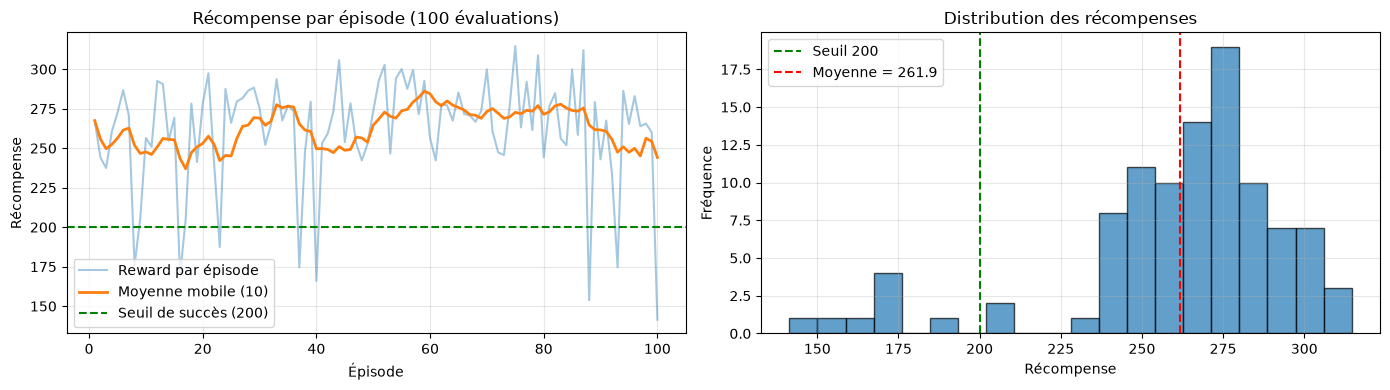

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data/eval_logs.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Courbe des récompenses
axes[0].plot(df["episode"], df["reward"], alpha=0.4, label="Reward par épisode")
axes[0].plot(df["episode"], df["reward"].rolling(window=10, min_periods=1).mean(),
             label="Moyenne mobile (10)", linewidth=2)
axes[0].axhline(y=200, color="green", linestyle="--", label="Seuil de succès (200)")
axes[0].set_xlabel("Épisode")
axes[0].set_ylabel("Récompense")
axes[0].set_title("Récompense par épisode (100 évaluations)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogramme
axes[1].hist(df["reward"], bins=20, edgecolor="black", alpha=0.7)
axes[1].axvline(x=200, color="green", linestyle="--", label="Seuil 200")
axes[1].axvline(x=df["reward"].mean(), color="red", linestyle="--", label=f"Moyenne = {df['reward'].mean():.1f}")
axes[1].set_xlabel("Récompense")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des récompenses")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id="6-format"></a>
## 6. Formatage des données pour l'API

### Flux RL : état → action

Le contrat de l'API suit le cycle fondamental du RL :

```
[ Client ] --(état : 8 floats)--> [ API ] --(action : entier 0-3)--> [ Client ]
```

### Format des états

L'API attend un JSON avec une liste de **8 valeurs flottantes** :

```json
{
  "state": [0.0, 1.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  "deterministic": true
}
```

Côté serveur, on convertit en `np.ndarray` (`dtype=float32`), format attendu par `model.predict()` de Stable-Baselines3. Cette conversion est nécessaire car PyTorch (sous le capot de SB3) travaille avec des tenseurs float32.

### Format des actions

L'API renvoie un **entier discret** (0-3) accompagné de son libellé humain :

```json
{
  "action": 2,
  "action_label": "propulseur principal"
}
```

Le libellé permet au client (GUI, dashboard) d'afficher une information lisible sans avoir à reconstruire le mapping.

### Format des récompenses

Les récompenses sont retournées en **float arrondi à 2 décimales** pour limiter la taille du payload sans perdre de précision utile.

### Endpoints

| Endpoint | Méthode | Entrée | Sortie | Usage |
|---|---|---|---|---|
| `/health` | GET | — | `{status, model_loaded}` | Vérifier que l'API tourne |
| `/info` | GET | — | métadonnées modèle + env | Pour le GUI/dashboard, afficher les noms d'actions |
| `/predict` | POST | `{state: [8 floats]}` | `{action, action_label}` | Décision atomique : 1 état → 1 action |
| `/play` | POST | `{seed?, max_steps?}` | trajectoire complète + métriques | Joue un épisode entier, utilisé par le GUI |

### Choix d'architecture

- **FastAPI** plutôt que Flask : génération automatique de la doc OpenAPI/Swagger sur `/docs`, validation automatique via Pydantic, support async natif.
- **Modèle chargé une seule fois** au démarrage (pas à chaque requête) → latence minimale.
- **Toute la logique RL côté serveur** : le client n'a jamais besoin d'embarquer SB3 / PyTorch.

Le code complet de l'API est dans `api/main.py`.

<a id="7-livrables"></a>
## 7. Livrables annexes

### Vidéo (`videos/eagle1_demo.mp4`)

Vidéo de 22.7 secondes concaténant 5 atterrissages réussis du meilleur modèle.
Générée avec `gymnasium.wrappers.RecordVideo` + concaténation MoviePy.

### API (`api/main.py`)

API FastAPI exposant le modèle. Voir section 6 pour le contrat de données.

**Lancement** :
```bash
uvicorn api.main:app --port 8000
```

Documentation interactive auto-générée : http://localhost:8000/docs

### GUI (`gui/app.py`)

Interface graphique Streamlit qui appelle l'API `/play` pour récupérer une trajectoire, puis rejoue l'épisode localement avec `env.render()` pour produire une animation visuelle frame par frame. L'utilisateur peut choisir la seed et la vitesse de lecture.

**Justification Streamlit** : prototypage très rapide (pas de HTML/JS à écrire), composants natifs pour les sliders/boutons/images, parfait pour une démo locale.

**Lancement** :
```bash
streamlit run gui/app.py
```

### Tableau de bord (`dashboard/dashboard.py`)

Dashboard Streamlit qui charge `data/eval_logs.csv` et affiche :

- **5 KPIs** : nombre d'épisodes, reward moyen, écart-type, taux de succès, taux d'atterrissages doux
- **Récompense par épisode** (avec seuil 200 en référence)
- **Moyenne mobile** (fenêtre 10)
- **Distribution des récompenses** (histogramme)
- **Longueur des épisodes**
- **Répartition succès/échec et doux/brutal**
- **Position finale d'atterrissage** (scatter coloré par succès)
- **Données brutes** (tableau filtrable)

**Filtres interactifs** dans la sidebar :
- Plage d'épisodes (slider)
- Résultat (succès / échec)
- Type d'atterrissage (doux / brutal)

**Justification Streamlit (vs Looker Studio)** : Looker Studio nécessite d'héberger les données dans le cloud, ce qui ne respecte pas la contrainte du brief "**prototype local sans dépendance à des serveurs externes**". Streamlit s'exécute en pur local, à partir d'un CSV local.

<a id="8-conclusion"></a>
## 8. Conclusion

### Performance atteinte

| Métrique | Cible (brief) | Obtenu |
|---|---|---|
| Récompense moyenne sur 100 épisodes | ≥ 200 | **~270** ✅ |
| Stabilité (écart-type) | faible | **~37** ✅ |
| Taux d'atterrissages réussis | non quantifié | **96/100** ✅ |
| Taux d'atterrissages doux | non quantifié | **85/100** ✅ |

### Choix techniques majeurs

1. **Algorithme DQN** — adapté à l'espace d'action discret de LunarLander-v3.
2. **Hyperparamètres RL Zoo** — gain massif vs valeurs par défaut, validés par la communauté.
3. **EvalCallback** — sauvegarde automatique du meilleur modèle, contre le *catastrophic forgetting* de DQN.
4. **FastAPI** — contrat clair `state → action`, doc auto, séparation backend/frontend respectée.
5. **Streamlit** — GUI et dashboard 100% locaux, conformes à la contrainte "pas de serveur externe".

### Améliorations possibles

- **Tester PPO** sur le même environnement : potentiellement plus stable, mais probablement moins sample-efficient que DQN sur un espace discret.
- **Recherche d'hyperparamètres systématique** avec Optuna : aller au-delà des valeurs RL Zoo.
- **Variantes avancées** : Double DQN, Dueling DQN, Prioritized Experience Replay pour réduire encore la variance.
- **Récompense personnalisée** : pénaliser plus fortement la consommation de carburant si c'est le KPI principal de l'entreprise.